# 05 — Modelo: Árvore de Decisão

Implementação do modelo de Árvore de Decisão com Scikit-Learn.

**Etapas obrigatórias (conforme projeto da disciplina):**
1. Construir árvore com instância de treino
2. Plotar árvore e computar E_in e E_out para analisar overfitting
3. Regularizar alpha via Minimal Cost-Complexity com cross validation
   - Encontrar a árvore que minimize: Pureza(T) + α · #folhas(T)
   - Tamanho do fold definido pela dimensão do conjunto de treino
4. Plotar e computar métricas da melhor árvore

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

from src.models import build_decision_tree, prune_decision_tree
from src.evaluation import (
    compute_metrics,
    compute_ein_eout,
    plot_confusion_matrix,
    print_classification_report,
)
from src.utils import save_model, FIGURES_DIR, DATA_PROCESSED

%matplotlib inline

In [2]:
X_train = np.load(DATA_PROCESSED / 'X_train.npy')
X_test  = np.load(DATA_PROCESSED / 'X_test.npy')
y_train = np.load(DATA_PROCESSED / 'y_train.npy')
y_test  = np.load(DATA_PROCESSED / 'y_test.npy')

feature_names = (DATA_PROCESSED / 'feature_names.txt').read_text().splitlines()

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Features: {feature_names}")

Treino: (4456, 15) | Teste: (1114, 15)
Features: ['pop_total', 'pop_urbana_pct', 'perc_jovens_15_29', 'renda_per_capita', 'taxa_desemprego', 'taxa_analfabetismo_15', 'perc_esgoto_adequado', 'gini', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao', 'perc_pobres', 'pib_per_capita', 'densidade_demografica']


## 5.1 Árvore sem poda (análise de overfitting)

Uma árvore sem restrições cresce até separar perfeitamente o treino, memorizando ruído. Isso resulta em E_in ≈ 0 e E_out alto — overfitting clássico.

In [3]:
tree_unpruned = build_decision_tree()
tree_unpruned.fit(X_train, y_train)

errors = compute_ein_eout(tree_unpruned, X_train, y_train, X_test, y_test)
print(f"Árvore SEM poda:")
print(f"  Profundidade máxima:  {tree_unpruned.get_depth()}")
print(f"  Número de folhas:     {tree_unpruned.get_n_leaves()}")
print(f"  E_in  = {errors['E_in']:.4f}  ({errors['E_in']*100:.2f}%)")
print(f"  E_out = {errors['E_out']:.4f} ({errors['E_out']*100:.2f}%)")
print(f"  Gap   = {errors['gap']:.4f}  → Overfitting: {'Sim' if errors['overfitting'] else 'Não'}")

Árvore SEM poda:
  Profundidade máxima:  24
  Número de folhas:     821
  E_in  = 0.0000  (0.00%)
  E_out = 0.3932 (39.32%)
  Gap   = 0.3932  → Overfitting: Sim


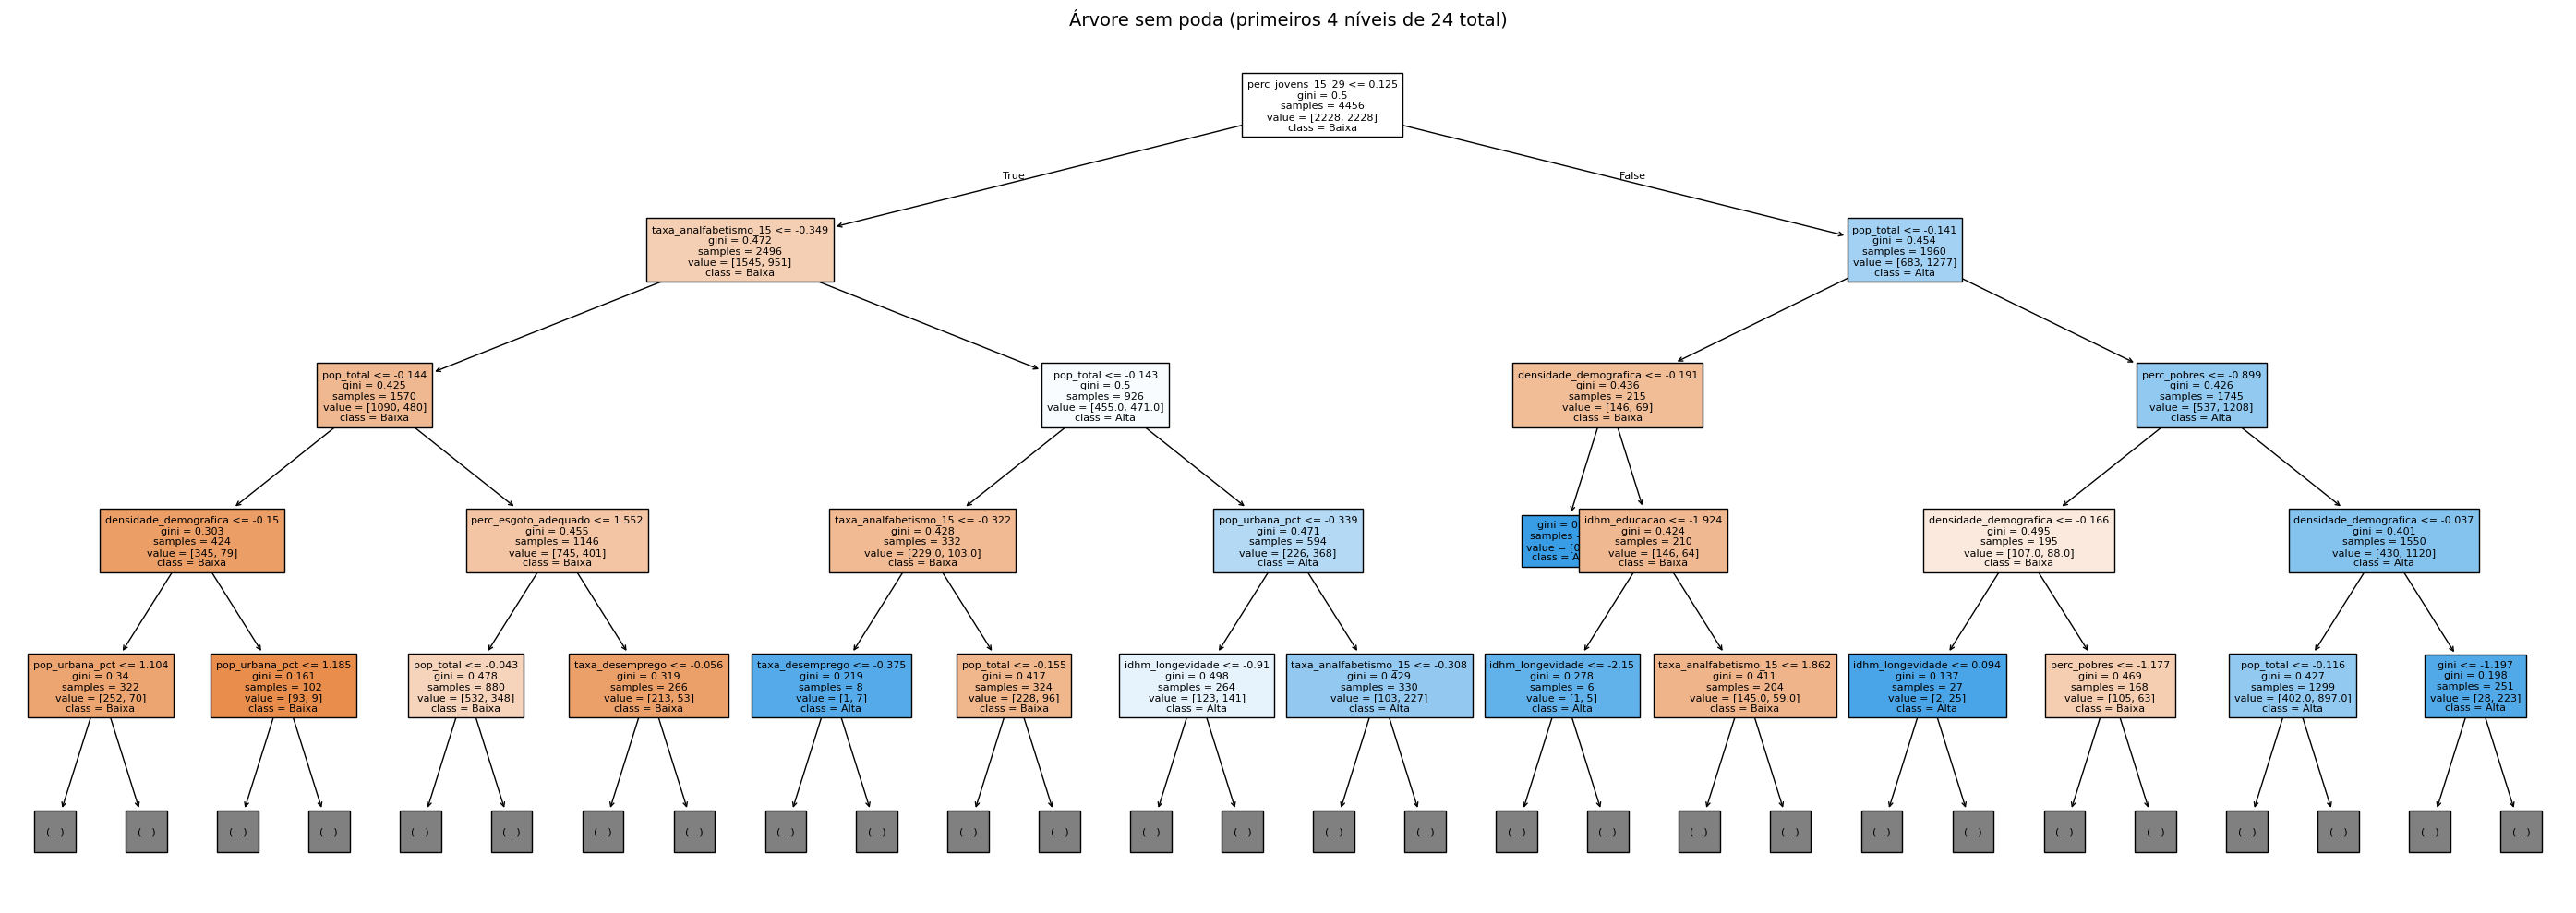

In [4]:
# A árvore completa é grande demais para visualizar detalhadamente.
# Plotamos com profundidade máxima = 4 para legibilidade.
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    tree_unpruned,
    max_depth=4,
    filled=True,
    feature_names=feature_names,
    class_names=['Baixa', 'Alta'],
    ax=ax,
    fontsize=8,
    impurity=True,
    proportion=False,
)
ax.set_title(f'Árvore sem poda (primeiros 4 níveis de {tree_unpruned.get_depth()} total)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_tree_unpruned.png', dpi=120, bbox_inches='tight')
plt.show()

## 5.2 Regularização via Minimal Cost-Complexity

O algoritmo de **Minimal Cost-Complexity Pruning** (Breiman et al., 1984) poda a árvore iterativamente, minimizando:

$$R_\alpha(T) = R(T) + \alpha \cdot |T|$$

onde R(T) é o erro de classificação e |T| o número de folhas. Para cada α, existe uma subárvore ótima T(α). O α ótimo é selecionado por **cross-validation de 10 folds** sobre os dados de treino.

**Justificativa de cv=10 e scoring='f1':**
- Com N=4.456, 10 folds → ~446 amostras/fold para validação e ~4.010 para treino interno (menor viés de estimativa que 5-fold).
- `scoring='f1'` é mais adequado que `'accuracy'` para classificação binária: ambas as métricas são equivalentes com classes 50/50, mas F1 é mais sensível a diferenças entre modelos na fronteira de decisão, revelando alphas ótimos distintos.

**Regra 1-SE (one standard error rule):** Apresentada como alternativa — seleciona o modelo mais simples cujo score CV está dentro de 1 desvio padrão do máximo. Favorece interpretabilidade em troca de leve queda de desempenho.

In [5]:
best_tree, cv_results = prune_decision_tree(
    X_train, y_train, cv_folds=10, scoring='f1', random_state=42
)

alphas      = cv_results['alphas']
mean_scores = cv_results['mean_scores']
std_scores  = cv_results['std_scores']

print(f"Número de alphas avaliados: {len(alphas)}")
print(f"CV: {cv_results['cv_folds']}-fold | Scoring: {cv_results['scoring']}")
print(f"\n--- Alpha ótimo (max F1-CV) ---")
print(f"  Alpha:          {cv_results['best_alpha']:.6f}")
print(f"  F1 médio CV:    {cv_results['best_cv_score']:.4f}")
print(f"  Idx no caminho: {cv_results['best_idx']} / {len(alphas)}")
print(f"\n--- Alpha pela Regra 1-SE (modelo mais simples dentro de 1 std do máximo) ---")
print(f"  Alpha 1-SE:     {cv_results['best_alpha_1se']:.6f}")
print(f"  F1 médio CV:    {cv_results['best_cv_score_1se']:.4f}")
print(f"  Threshold 1-SE: {cv_results['best_cv_score'] - std_scores[cv_results['best_idx']]:.4f}")

Número de alphas avaliados: 415
CV: 10-fold | Scoring: f1

--- Alpha ótimo (max F1-CV) ---
  Alpha:          0.002514
  F1 médio CV:    0.6865
  Idx no caminho: 407 / 415

--- Alpha pela Regra 1-SE (modelo mais simples dentro de 1 std do máximo) ---
  Alpha 1-SE:     0.009144
  F1 médio CV:    0.6630
  Threshold 1-SE: 0.6541


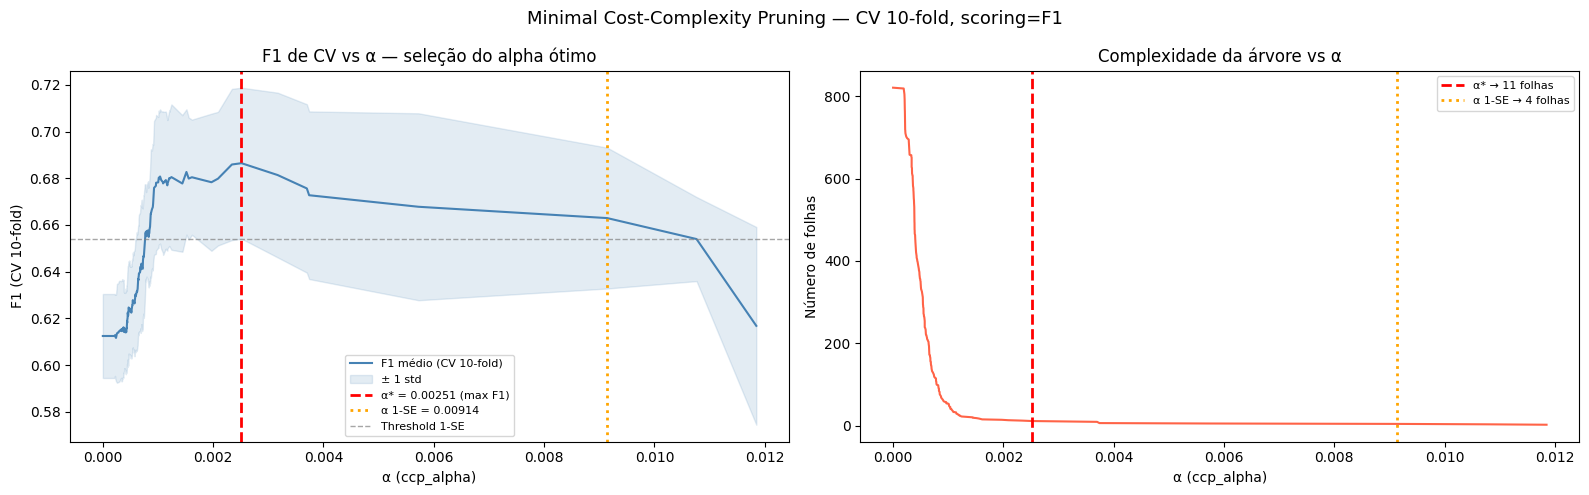


Comparação no conjunto de teste:
Modelo                Prof  Folhas      F1     Acc
Alpha ótimo              5      11  0.6637  0.6580
Alpha 1-SE               2       4  0.6312  0.6077

Decisão: usar Alpha ótimo (max F1-CV) — melhor F1 no teste, gap aceitável.


In [6]:
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.metrics import f1_score as f1

best_idx     = cv_results['best_idx']
best_idx_1se = cv_results['best_idx_1se']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# F1-CV vs Alpha
axes[0].plot(alphas, mean_scores, color='steelblue', linewidth=1.5, label='F1 médio (CV 10-fold)')
axes[0].fill_between(alphas, mean_scores - std_scores, mean_scores + std_scores,
                     alpha=0.15, color='steelblue', label='± 1 std')
axes[0].axvline(cv_results['best_alpha'], color='red', linestyle='--', linewidth=2,
                label=f"α* = {cv_results['best_alpha']:.5f} (max F1)")
axes[0].axvline(cv_results['best_alpha_1se'], color='orange', linestyle=':', linewidth=2,
                label=f"α 1-SE = {cv_results['best_alpha_1se']:.5f}")
axes[0].axhline(cv_results['best_cv_score'] - std_scores[best_idx],
                color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Threshold 1-SE')
axes[0].set_xlabel('α (ccp_alpha)')
axes[0].set_ylabel('F1 (CV 10-fold)')
axes[0].set_title('F1 de CV vs α — seleção do alpha ótimo')
axes[0].legend(fontsize=8)

# Número de folhas vs Alpha
n_leaves_list = []
for a in alphas:
    t = DTC(ccp_alpha=a, random_state=42)
    t.fit(X_train, y_train)
    n_leaves_list.append(t.get_n_leaves())

axes[1].plot(alphas, n_leaves_list, color='tomato', linewidth=1.5)
axes[1].axvline(cv_results['best_alpha'], color='red', linestyle='--', linewidth=2,
                label=f"α* → {best_tree.get_n_leaves()} folhas")
t_1se = DTC(ccp_alpha=cv_results['best_alpha_1se'], random_state=42)
t_1se.fit(X_train, y_train)
axes[1].axvline(cv_results['best_alpha_1se'], color='orange', linestyle=':', linewidth=2,
                label=f"α 1-SE → {t_1se.get_n_leaves()} folhas")
axes[1].set_xlabel('α (ccp_alpha)')
axes[1].set_ylabel('Número de folhas')
axes[1].set_title('Complexidade da árvore vs α')
axes[1].legend(fontsize=8)

plt.suptitle('Minimal Cost-Complexity Pruning — CV 10-fold, scoring=F1', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_tree_alpha_cv.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparação direta: alpha ótimo vs 1-SE no conjunto de teste
y_pred_opt = best_tree.predict(X_test)
y_pred_1se = t_1se.predict(X_test)

print(f"\nComparação no conjunto de teste:")
print(f"{'Modelo':<20} {'Prof':>5} {'Folhas':>7} {'F1':>7} {'Acc':>7}")
print(f"{'Alpha ótimo':<20} {best_tree.get_depth():>5} {best_tree.get_n_leaves():>7} "
      f"{f1(y_test, y_pred_opt):>7.4f} {(y_test==y_pred_opt).mean():>7.4f}")
print(f"{'Alpha 1-SE':<20} {t_1se.get_depth():>5} {t_1se.get_n_leaves():>7} "
      f"{f1(y_test, y_pred_1se):>7.4f} {(y_test==y_pred_1se).mean():>7.4f}")
print(f"\nDecisão: usar Alpha ótimo (max F1-CV) — melhor F1 no teste, gap aceitável.")

## 5.3 Melhor árvore (podada)

Visualização da árvore podada com o α ótimo encontrado por cross-validation.

Árvore podada (α=0.002514):
  Profundidade: 5
  Folhas:       11


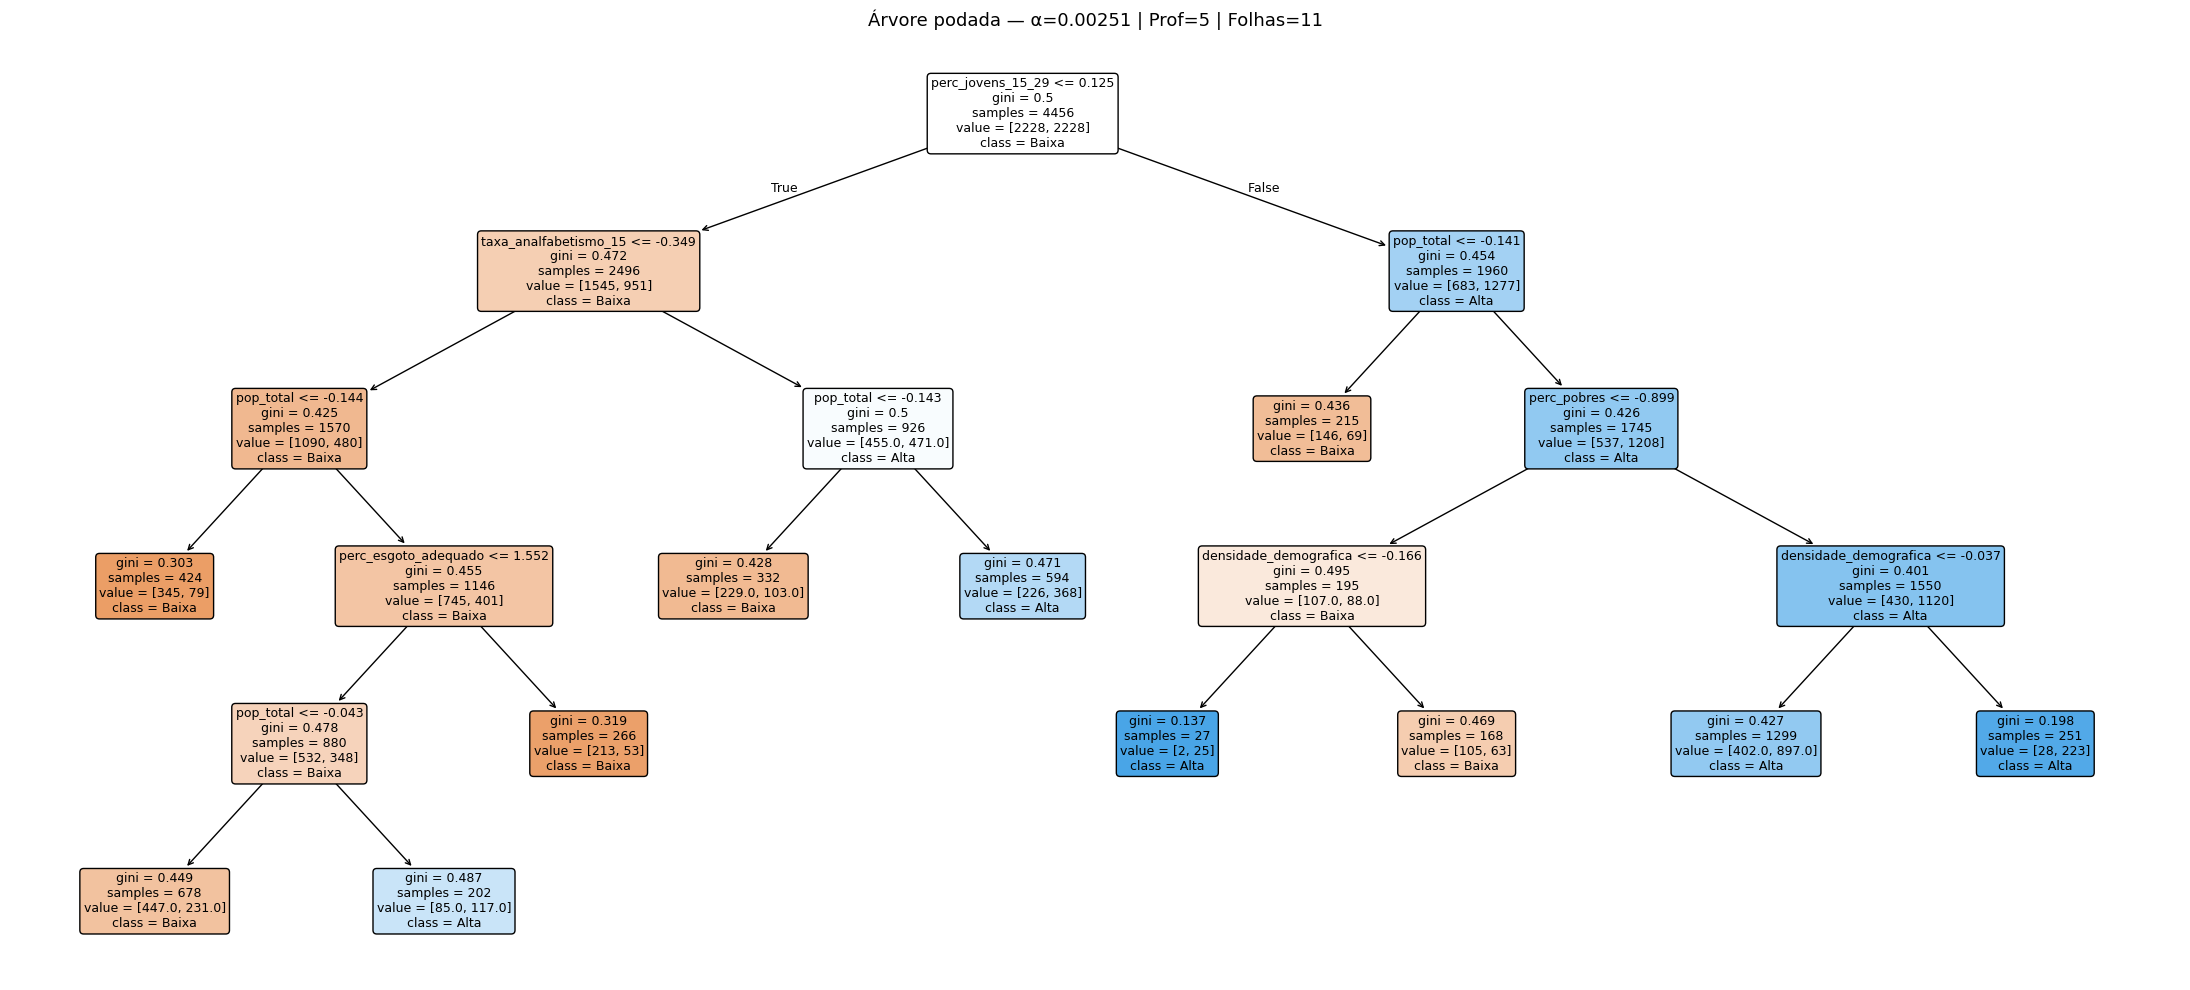

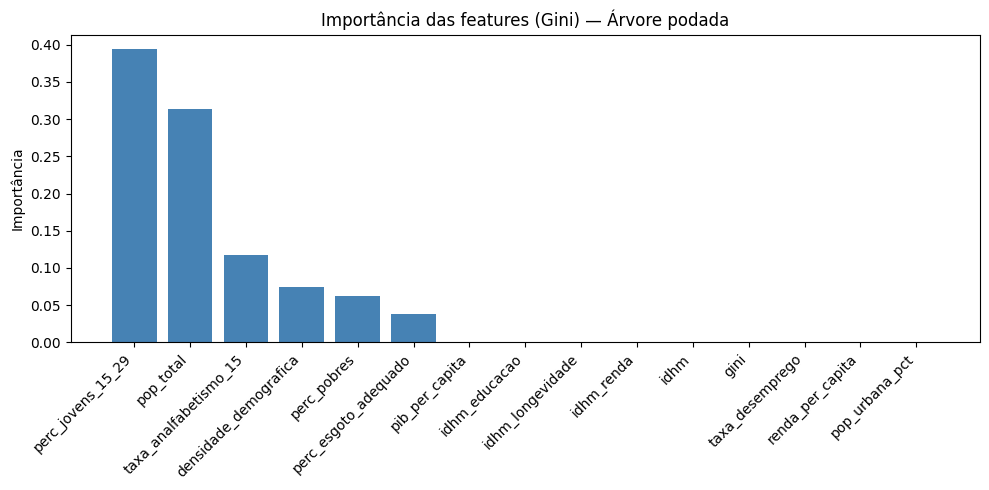

In [7]:
print(f"Árvore podada (α={cv_results['best_alpha']:.6f}):")
print(f"  Profundidade: {best_tree.get_depth()}")
print(f"  Folhas:       {best_tree.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_tree,
    filled=True,
    feature_names=feature_names,
    class_names=['Baixa', 'Alta'],
    ax=ax,
    fontsize=9,
    impurity=True,
    proportion=False,
    rounded=True,
)
ax.set_title(f'Árvore podada — α={cv_results["best_alpha"]:.5f} | Prof={best_tree.get_depth()} | Folhas={best_tree.get_n_leaves()}', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_tree_pruned.png', dpi=130, bbox_inches='tight')
plt.show()

# Importância das features
importances = best_tree.feature_importances_
sorted_idx = importances.argsort()[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(importances)), importances[sorted_idx], color='steelblue')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_title('Importância das features (Gini) — Árvore podada')
ax.set_ylabel('Importância')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_tree_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Métricas de Qualidade

E_in  = 0.3009  (30.09%)
E_out = 0.3420 (34.20%)
Gap   = 0.0411  → Overfitting: Não

Relatório de Classificação — Árvore de Decisão (podada)
                 precision    recall  f1-score   support

Baixa Violência       0.66      0.64      0.65       557
 Alta Violência       0.65      0.68      0.66       557

       accuracy                           0.66      1114
      macro avg       0.66      0.66      0.66      1114
   weighted avg       0.66      0.66      0.66      1114



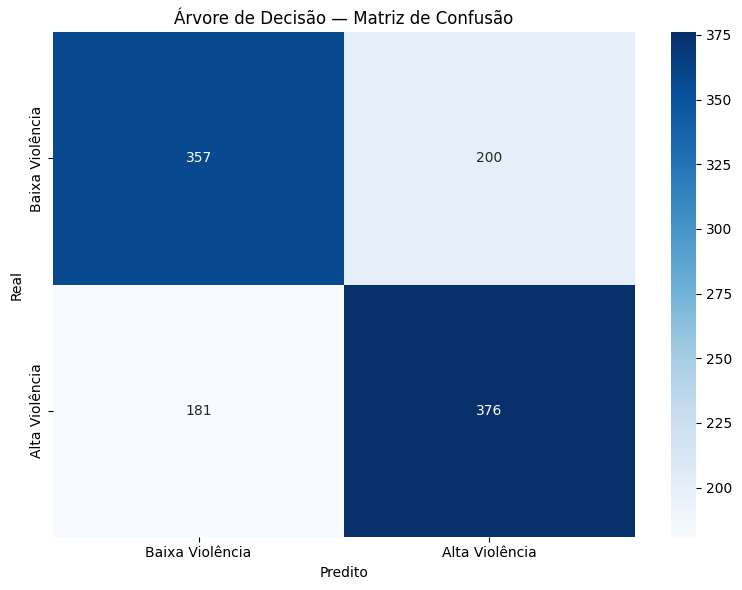


Métricas no conjunto de teste:
  accuracy: 0.6580
  precision: 0.6528
  recall: 0.6750
  f1_score: 0.6637


In [8]:
errors_pruned = compute_ein_eout(best_tree, X_train, y_train, X_test, y_test)
print(f"E_in  = {errors_pruned['E_in']:.4f}  ({errors_pruned['E_in']*100:.2f}%)")
print(f"E_out = {errors_pruned['E_out']:.4f} ({errors_pruned['E_out']*100:.2f}%)")
print(f"Gap   = {errors_pruned['gap']:.4f}  → Overfitting: {'Sim' if errors_pruned['overfitting'] else 'Não'}")

y_pred = best_tree.predict(X_test)
print_classification_report(y_test, y_pred, 'Árvore de Decisão (podada)')
plot_confusion_matrix(y_test, y_pred, 'Árvore de Decisão — Matriz de Confusão',
                      save_path=str(FIGURES_DIR / '05_tree_confusion.png'))

metrics = compute_metrics(y_test, y_pred)
print("\nMétricas no conjunto de teste:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

In [9]:
save_model(best_tree, 'decision_tree')
print("Modelo salvo em models/decision_tree.joblib")

Modelo salvo em models/decision_tree.joblib
